# SVM

## Linear SVM vs Logistic Regression

In [274]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_circles, make_moons, load_breast_cancer
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report

In [ ]:
def plot_decision_boundary(clf, X, y, scaler=None, ax=None, levels=[0], **contour_kwargs):
    if ax is None:
        ax = plt.gca()
    
    # Определяем границы графика по исходным данным
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    # Подготовка координат для передачи в классификатор
    grid = np.c_[xx.ravel(), yy.ravel()]
    if scaler is not None:
        grid = scaler.transform(grid)
    
    # Вычисляем decision_function
    Z = clf.decision_function(grid)
    Z = Z.reshape(xx.shape)
    
    # Рисуем контур на указанных уровнях
    ax.contour(xx, yy, Z, levels=levels, **contour_kwargs)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal')

    return ax


In [118]:
def plot_linear_svc_decision_boundaries(svc, X, y, scaler=None, ax=None):
    if ax is None:
        ax = plt.gca()
        
    # Рисуем разделяющую границу
    plot_decision_boundary(svc, X, y, scaler=scaler, ax=ax, 
                           levels=[0], colors='k', linewidths=2, linestyles='-')

    # Рисуем границы полей (-1, 1)
    plot_decision_boundary(svc, X, y, scaler=scaler, ax=ax,
                            levels=[-1, 1], colors='k', linewidths=2, linestyles='--', alpha=0.4)
    
    # Рисуем опорные векторы
    if hasattr(svc, 'support_vectors_'):
        sv = svc.support_vectors_
        if scaler is not None:
            sv = scaler.inverse_transform(sv)
        ax.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', edgecolors='k', linewidths=2, label='Опорные векторы')
        ax.legend(loc='best')
        
    return ax

In [119]:
# Generate data
X, y = make_blobs(
    n_samples=200,
    centers=2,
    random_state=42,
    cluster_std=1.5,
)

# convert y to {-1, 1}
y = 2 * y - 1 #

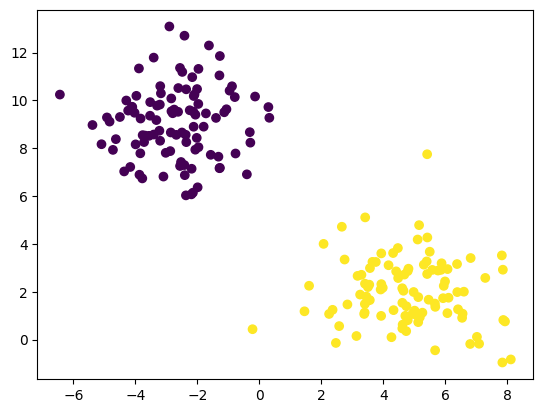

In [120]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [1]:
# fit and compare decision boundaries of linear SVC with different C

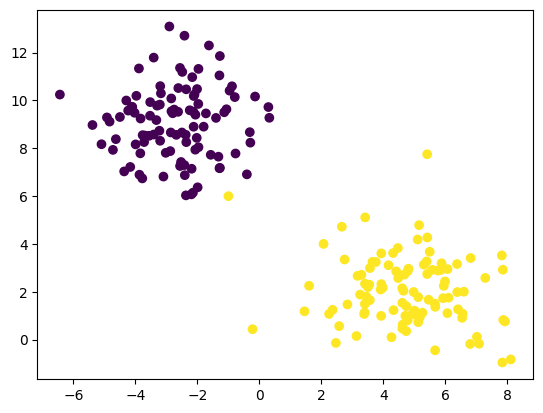

In [ ]:
# add outlier

X_outlier = np.array([[-1, 6]])
y_outlier = np.array([1])
X = np.vstack([X, X_outlier])
y = np.hstack([y, y_outlier])

plt.scatter(X[:, 0], X[:, 1], c=y)

In [2]:
# compare again

In [3]:
# Task:
#   count and plot the number of support vectors as a function of C

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
n_sv = []

## Non-linearly separable data

In [4]:
# Generate data

X, y = make_circles(
    n_samples=200,
    factor=0.5,
    noise=0.1,
    random_state=42,
)
y = 2 * y - 1 # y -> {-1, 1}

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', alpha=0.7)
plt.gca().set_aspect('equal')
plt.show()

NameError: name 'make_circles' is not defined

In [5]:
# fit:
#   linear SVC
#   Kernel SVC with RBF kernel
#   Kernel SVC with polynomial kernel d=2

In [ ]:
# compare accuracy, number of support vectors

## Масштабирование признаков

In [221]:
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=2.0)
y = 2 * y - 1  # метки -1, 1

X_scaled = X.copy()
X_scaled[:, 1] = X_scaled[:, 1] * 1000


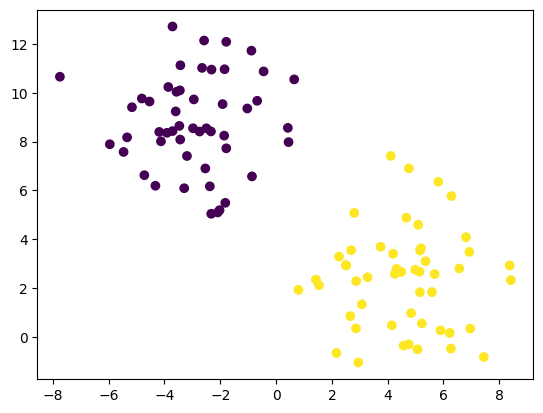

In [222]:
plt.scatter(X[:, 0], X[:, 1], c=y)

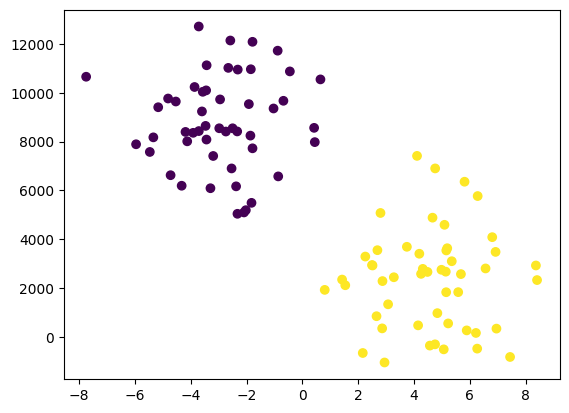

In [223]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)

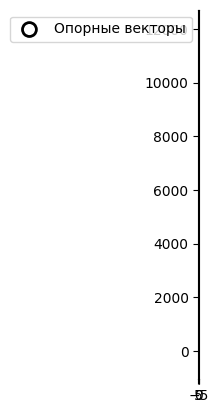

In [229]:
classifier = SVC(kernel='rbf', gamma='scale', C=1, random_state=42)
classifier.fit(X_scaled, y)
acc_no_scaler = classifier.score(X_scaled, y)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
plot_linear_svc_decision_boundaries(classifier, X_scaled, y, scaler=None, ax=plt.gca())
plt.show()

In [232]:
svc_linear_no_scaler = SVC(kernel='linear', C=1, random_state=42)
svc_linear_no_scaler.fit(X_scaled, y)
print("Линейный SVC без масштабирования:")
print(f"  Коэффициенты: {svc_linear_no_scaler.coef_[0]}")
print(f"  Свободный член: {svc_linear_no_scaler.intercept_[0]:.2f}")
print(f"  Количество опорных векторов: {len(svc_linear_no_scaler.support_vectors_)}")

Линейный SVC без масштабирования:
  Коэффициенты: [ 4.84052051e-01 -3.06514225e-04]
  Свободный член: 1.17
  Количество опорных векторов: 4


## Hyperparameters tuning

In [239]:
digits = load_digits()
X, y = digits.data, digits.target

# laeve only 4 and 9 for binary classification
mask = (y == 4) | (y == 9)
X_bin = X[mask]
y_bin = y[mask]
y_bin = 2 * (y_bin == 9) - 1

print(f"Размер выборки: {X_bin.shape}")
print(f"Классы: {np.unique(y_bin)} (4 -> -1, 9 -> +1)")

Размер выборки: (361, 64)
Классы: [-1  1] (4 -> -1, 9 -> +1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', random_state=42))
])

# fit grid_search by cross-validation for different C and gamma values
# let c be in [0.1, 1, 10, 100]
# let gamma be in [0.001, 0.01, 0.1, 1, 'scale', 'auto']

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc', SVC(random_state=42))]),
             n_jobs=-1,
             param_grid={'svc__C': [0.1, 1, 10, 100],
                         'svc__gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto']},
             return_train_score=True, scoring='accuracy', verbose=1)

Точность на тесте: 1.0000


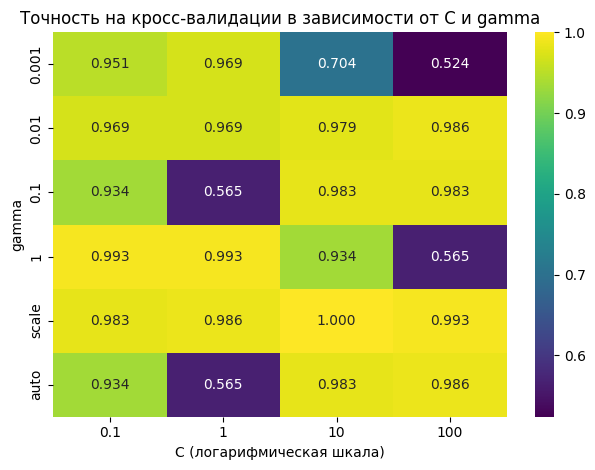

In [ ]:
# plot results

y_pred = grid_search.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print("Точность на тесте: {:.4f}".format(test_acc))

results = grid_search.cv_results_
C_values = param_grid['svc__C']
gamma_values = param_grid['svc__gamma']

mean_test_scores = results['mean_test_score'].reshape(len(gamma_values), len(C_values))

sns.heatmap(mean_test_scores,
            xticklabels=C_values,
            yticklabels=gamma_values,
            annot=True, fmt='.3f', cmap='viridis')
plt.xlabel('C')
plt.ylabel('gamma')
plt.title('Точность на кросс-валидации в зависимости от C и gamma')
plt.tight_layout()
plt.show()

## NuSVM

In [ ]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

print(f"Размер данных: {X.shape}")
print(f"Распределение классов: {np.bincount(y)} (злокачественная - доброкачественная)")

Размер данных: (569, 30)
Распределение классов: [212 357] (0: злокач., 1: доброкач.)


In [276]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('nusvc', NuSVC(kernel='rbf', gamma='scale', nu=0.5, random_state=42))
])

In [6]:
base_pipe.fit(X_train, y_train)
y_pred_base = base_pipe.predict(X_test)

print("Базовая модель (nu=0.5)")
print(f"Точность на тесте: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Доля опорных векторов: {len(base_pipe.named_steps['nusvc'].support_vectors_) / len(X_train):.4f}")
print(f"Число опорных векторов: {len(base_pipe.named_steps['nusvc'].support_vectors_)}")

NameError: name 'base_pipe' is not defined

In [ ]:
nu_values = [0.01, 0.05, 0.1, 0.2, 0.5, 0.7]
train_errors = []
sv_fractions = []

for nu in nu_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('nusvc', NuSVC(kernel='rbf', gamma='scale', nu=nu, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    y_train_pred = pipe.predict(X_train)

    # Доля ошибок на обучении
    err = 1 - accuracy_score(y_train, y_train_pred)
    train_errors.append(err)
    sv_frac = len(pipe.named_steps['nusvc'].support_vectors_) / len(X_train)
    sv_fractions.append(sv_frac)
    print(f"nu={nu:.2f}: train_error={err:.4f} (≤{nu:.2f}? {err <= nu}), SV fraction={sv_frac:.4f} (≥{nu:.2f}? {sv_frac >= nu})")

nu=0.01: train_error=0.0000 (≤0.01? True), SV fraction=0.1429 (≥0.01? True)
nu=0.05: train_error=0.0066 (≤0.05? True), SV fraction=0.1846 (≥0.05? True)
nu=0.10: train_error=0.0132 (≤0.10? True), SV fraction=0.1846 (≥0.10? True)
nu=0.20: train_error=0.0176 (≤0.20? True), SV fraction=0.2549 (≥0.20? True)
nu=0.50: train_error=0.0505 (≤0.50? True), SV fraction=0.5187 (≥0.50? True)
nu=0.70: train_error=0.0505 (≤0.70? True), SV fraction=0.7055 (≥0.70? True)
